In [10]:
# ============================================================
# Multi-Model DewPoint TRUE FORECASTING
# SARIMA, Prophet, LSTM, PatchTST
# ============================================================
# Data: ~100 years of DAILY avg Temperature & Humidity & DewPoint
# Training: on historical data up to 2011
# Forecasting: DewPoint for 2012-2021 WITHOUT using future T or H
# Evaluation: daily predictions aggregated to monthly averages
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


In [11]:
# Load daily data
#df = pd.read_csv("df_linear_merged.csv", parse_dates=["Date"])
df = pd.read_csv("/kaggle/input/datasets/celaleddinomersaglam/weather-dew2/df_linear_merged.csv", parse_dates=["Date"])

df = df.sort_values("Date").reset_index(drop=True)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Train/test split: train on everything up to 2011, test on 2012-2021
train_daily = df[df["Year"] <= 2011].copy()
test_daily = df[df["Year"] >= 2012].copy()

# Ground truth: actual monthly averages for test period (for evaluation)
true_monthly = test_daily.groupby(["Year", "Month"]).agg(
    DewPoint=("DewPoint", "mean")
).reset_index()
true_monthly_dew = true_monthly["DewPoint"].values

print(f"Daily data shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Train: {len(train_daily)} days | Test: {len(test_daily)} days")
print(f"Test months: {len(true_monthly)}")
print()
print("NOTE: Models will forecast DewPoint for 2012-2021")
print("      WITHOUT using future Temperature or Humidity.")
df.head()

Daily data shape: (40260, 6)
Date range: 1912-01-01 to 2021-12-31
Train: 36600 days | Test: 3660 days
Test months: 120

NOTE: Models will forecast DewPoint for 2012-2021
      WITHOUT using future Temperature or Humidity.


,Date,Temperature,Humidity,DewPoint,Year,Month
0,1912-01-01,3.1,83.0,0.492561,1912,1
1,1912-01-02,2.7,97.0,2.271348,1912,1
2,1912-01-03,-0.3,100.0,-0.300000,1912,1
3,1912-01-04,2.7,100.0,2.700000,1912,1
4,1912-01-05,7.4,73.0,2.875258,1912,1


In [12]:
# Dictionary to store monthly-averaged results from all models
# Each entry: model_name -> {"pred_monthly": array, "true_monthly": array}
all_results = {}

def daily_to_monthly(dates, values):
    """Aggregate daily predictions to monthly averages."""
    tmp = pd.DataFrame({"Date": dates, "pred": values})
    tmp["Year"] = tmp["Date"].dt.year
    tmp["Month"] = tmp["Date"].dt.month
    monthly = tmp.groupby(["Year", "Month"])["pred"].mean().reset_index()
    monthly = monthly.sort_values(["Year", "Month"])
    return monthly["pred"].values

## Model 1: SARIMA (Seasonal ARIMA)
Univariate model — fitted on monthly DewPoint data only (no exogenous Temperature or Humidity).
Forecasts 120 months (10 years) into the future based purely on historical DewPoint patterns.

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Aggregate training data to monthly for SARIMA
train_monthly_sarima = train_daily.groupby(["Year", "Month"]).agg(
    DewPoint=("DewPoint", "mean"),
).reset_index()
train_monthly_sarima["Date"] = pd.to_datetime(
    train_monthly_sarima[["Year", "Month"]].assign(Day=1)
)
train_monthly_sarima = train_monthly_sarima.set_index("Date").sort_index()

# Fit SARIMAX: univariate (NO exogenous Temperature/Humidity)
print("Fitting SARIMAX model on monthly DewPoint (univariate)...")
sarima_model = SARIMAX(
    train_monthly_sarima["DewPoint"],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False, maxiter=500)
print(sarima_fit.summary().tables[0])

# Forecast 120 months ahead (no exogenous variables needed)
n_test_months = len(true_monthly)
sarima_pred_monthly = sarima_fit.forecast(steps=n_test_months).values

all_results["SARIMA"] = {"pred_monthly": sarima_pred_monthly, "true_monthly": true_monthly_dew}

sarima_mae = mean_absolute_error(true_monthly_dew, sarima_pred_monthly)
sarima_rmse = np.sqrt(mean_squared_error(true_monthly_dew, sarima_pred_monthly))
sarima_r2 = r2_score(true_monthly_dew, sarima_pred_monthly)
print(f"\nSARIMA Monthly DewPoint — MAE: {sarima_mae:.3f} | RMSE: {sarima_rmse:.3f} | R2: {sarima_r2:.4f}")

Fitting SARIMAX model on monthly DewPoint (univariate)...
                                     SARIMAX Results                                      
Dep. Variable:                           DewPoint   No. Observations:                 1200
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood               -2216.922
Date:                            Sat, 07 Mar 2026   AIC                           4443.845
Time:                                    03:45:55   BIC                           4469.186
Sample:                                01-01-1912   HQIC                          4453.401
                                     - 12-01-2011                                         
Covariance Type:                              opg                                         

SARIMA Monthly DewPoint — MAE: 1.535 | RMSE: 1.962 | R2: 0.9109


## Model 2: Prophet (Facebook/Meta)
Univariate model — fitted on daily DewPoint with yearly seasonality only.
No Temperature or Humidity regressors. Forecasts future dates directly.

In [14]:
from prophet import Prophet

# Prophet on daily data — univariate (no extra regressors)
prophet_train = pd.DataFrame({
    "ds": train_daily["Date"].values,
    "y": train_daily["DewPoint"].values,
})

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
)

print("Fitting Prophet on daily DewPoint (univariate, no T/H regressors)...")
m.fit(prophet_train)

# Create future dataframe directly from test dates
future = pd.DataFrame({"ds": pd.to_datetime(test_daily["Date"].values)})

prophet_forecast = m.predict(future)
prophet_pred_daily = prophet_forecast["yhat"].values

# Aggregate daily predictions to monthly (use forecast dates to ensure alignment)
prophet_pred_monthly = daily_to_monthly(prophet_forecast["ds"].values, prophet_pred_daily)

all_results["Prophet"] = {"pred_monthly": prophet_pred_monthly, "true_monthly": true_monthly_dew}

prophet_mae = mean_absolute_error(true_monthly_dew, prophet_pred_monthly)
prophet_rmse = np.sqrt(mean_squared_error(true_monthly_dew, prophet_pred_monthly))
prophet_r2 = r2_score(true_monthly_dew, prophet_pred_monthly)
print(f"Prophet Monthly DewPoint — MAE: {prophet_mae:.3f} | RMSE: {prophet_rmse:.3f} | R2: {prophet_r2:.4f}")

Fitting Prophet on daily DewPoint (univariate, no T/H regressors)...


03:45:56 - cmdstanpy - INFO - Chain [1] start processing
03:46:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet Monthly DewPoint — MAE: 1.582 | RMSE: 1.998 | R2: 0.9076


## Shared Data Preparation for Neural Network Models (LSTM & PatchTST)
Both NN models use a sliding window on daily data. Window = 365 days (1 year of history).

**Features:** `[DewPoint_scaled, doy_sin, doy_cos, year_norm]` — NO Temperature or Humidity.

**Test-time:** Autoregressive forecasting — predict one day, feed prediction back as input, repeat for all test days.

In [15]:
# Feature engineering on daily data  — NO Temperature or Humidity
df_nn = df.copy()

# Day-of-year cyclical encoding (captures yearly seasonality)
doy = df_nn["Date"].dt.dayofyear
df_nn["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
df_nn["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

# Year trend normalized to [0, 1]
year_min, year_max = df_nn["Year"].min(), df_nn["Year"].max()
df_nn["year_norm"] = (df_nn["Year"] - year_min) / (year_max - year_min)

train_mask = df_nn["Year"] <= 2011
val_mask = (df_nn["Year"] >= 2002) & (df_nn["Year"] <= 2011)
train_only_mask = df_nn["Year"] <= 2001

# Scale DewPoint ONLY (no Temperature or Humidity) using training data
scaler = StandardScaler()
scaler.fit(train_daily[["DewPoint"]])
df_nn["dew_scaled"] = scaler.transform(df_nn[["DewPoint"]])

WINDOW_SIZE = 365  # 1 year of daily history

# Features: DewPoint (scaled) + seasonal encodings + year trend
# NO Temperature or Humidity!
FEATURE_COLS = ["dew_scaled", "doy_sin", "doy_cos", "year_norm"]
NUM_FEATURES = len(FEATURE_COLS)
DEW_IDX = 0  # index of dew_scaled in FEATURE_COLS

class DailyClimateDataset(Dataset):
    """Sliding window dataset on daily data. Target: next day's DewPoint (scaled)."""
    def __init__(self, data, window_size=WINDOW_SIZE):
        self.data = torch.FloatTensor(data)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]        # (365, 4)
        y = self.data[idx + self.window_size, DEW_IDX]     # scalar: dew_scaled
        return x, y

all_data = df_nn[FEATURE_COLS].values
train_end = train_only_mask.sum()     # up to 2001-12-31
val_end = train_mask.sum()            # up to 2011-12-31

train_data = all_data[:train_end]
val_data = all_data[train_end - WINDOW_SIZE : val_end]

train_dataset = DailyClimateDataset(train_data)
val_dataset = DailyClimateDataset(val_data)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Store the last WINDOW_SIZE days of training data for autoregressive forecasting
initial_window = all_data[val_end - WINDOW_SIZE : val_end].copy()  # last 365 days of train

# Test dates for evaluation
test_dates_nn = df_nn.iloc[val_end:]["Date"].values
n_test_days = len(test_dates_nn)

print(f"Features: {FEATURE_COLS}")
print(f"NO Temperature or Humidity in features!")
print(f"Train samples: {len(train_dataset):,}, Val: {len(val_dataset):,}")
print(f"Input shape: ({WINDOW_SIZE}, {NUM_FEATURES}), Output: scalar (DewPoint)")
print(f"Test days to forecast autoregressively: {n_test_days}")
print(f"Test date range: {test_dates_nn[0]} to {test_dates_nn[-1]}")

Features: ['dew_scaled', 'doy_sin', 'doy_cos', 'year_norm']
NO Temperature or Humidity in features!
Train samples: 32,575, Val: 3,660
Input shape: (365, 4), Output: scalar (DewPoint)
Test days to forecast autoregressively: 3660
Test date range: 2012-01-01T00:00:00.000000000 to 2021-12-31T00:00:00.000000000


In [16]:
def train_nn_model(model, train_loader, val_loader, train_dataset, val_dataset,
                   num_epochs=50, patience=8, lr=1e-4):
    """Shared training loop for NN models."""
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    patience_counter = 0
    best_state = {k: v.clone() for k, v in model.state_dict().items()}

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            if torch.isnan(loss):
                print(f"  WARNING: NaN loss at epoch {epoch+1}, skipping batch")
                continue
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
        epoch_loss /= len(train_dataset)

        model.eval()
        epoch_val = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                loss = criterion(pred, y)
                epoch_val += loss.item() * x.size(0)
        epoch_val /= len(val_dataset)

        train_losses.append(epoch_loss)
        val_losses.append(epoch_val)
        scheduler.step()

        if not np.isnan(epoch_val) and epoch_val < best_val_loss:
            best_val_loss = epoch_val
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or patience_counter == 0:
            print(f"  Epoch {epoch+1:3d}/{num_epochs} | Train: {epoch_loss:.6f} | Val: {epoch_val:.6f} {'*' if patience_counter==0 else ''}")

        if patience_counter >= patience:
            print(f"  Early stop at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    print(f"  Best val loss: {best_val_loss:.6f}")
    return model, train_losses, val_losses


def forecast_nn_autoregressive(model, initial_window, n_days, test_dates, scaler):
    """
    Autoregressive forecasting for NN models.
    
    Starts with the last 365 days of training data as the initial window.
    Predicts one day at a time, feeds the prediction back into the window,
    and slides forward. Repeats for n_days.
    
    For each predicted day, doy_sin, doy_cos, and year_norm are computed
    from the actual calendar date (these are known in advance).
    Only DewPoint is predicted and fed back.
    """
    model.eval()
    window = initial_window.copy()  # shape: (365, 4)
    predictions_scaled = []
    
    dew_mean, dew_std = scaler.mean_[0], scaler.scale_[0]
    
    with torch.no_grad():
        for i in range(n_days):
            # Prepare input
            x = torch.FloatTensor(window).unsqueeze(0).to(device)  # (1, 365, 4)
            pred_scaled = model(x).item()  # predicted dew_scaled
            predictions_scaled.append(pred_scaled)
            
            # Compute known features for the next day
            date = pd.Timestamp(test_dates[i])
            doy = date.dayofyear
            doy_sin = np.sin(2 * np.pi * doy / 365.25)
            doy_cos = np.cos(2 * np.pi * doy / 365.25)
            year_norm = (date.year - year_min) / (year_max - year_min)
            
            # Create new row: [predicted dew_scaled, known doy_sin, doy_cos, year_norm]
            new_row = np.array([pred_scaled, doy_sin, doy_cos, year_norm])
            
            # Slide window: drop oldest day, append new prediction
            window = np.vstack([window[1:], new_row])
            
            if (i + 1) % 365 == 0:
                print(f"    Forecasted {i+1}/{n_days} days...")
    
    # Convert predictions to original scale
    predictions_scaled = np.array(predictions_scaled)
    predictions_daily = predictions_scaled * dew_std + dew_mean
    
    # Aggregate to monthly
    predictions_monthly = daily_to_monthly(test_dates, predictions_daily)
    
    return predictions_daily, predictions_monthly


print("Training and forecasting utilities ready.")
print("NOTE: forecast_nn_autoregressive predicts one day at a time,")
print("      feeding predictions back as input (no future T/H used).")

Training and forecasting utilities ready.
NOTE: forecast_nn_autoregressive predicts one day at a time,
      feeding predictions back as input (no future T/H used).


## Model 3: LSTM
2-layer LSTM on daily data (365-day window). Features: DewPoint + seasonality only.

**Autoregressive forecasting**: predict one day → feed back → repeat for ~3,650 days.

In [17]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=NUM_FEATURES, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)

lstm_model = LSTMModel()
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM parameters: {total_params:,}")

print("\nTraining LSTM on daily data (no T/H features)...")
lstm_model, lstm_train_losses, lstm_val_losses = train_nn_model(
    lstm_model, train_loader, val_loader, train_dataset, val_dataset,
    lr=3e-4
)

print("\nAutoregressive forecasting with LSTM...")
lstm_pred_daily, lstm_pred_monthly = forecast_nn_autoregressive(
    lstm_model, initial_window, n_test_days, test_dates_nn, scaler
)
all_results["LSTM"] = {"pred_monthly": lstm_pred_monthly, "true_monthly": true_monthly_dew}

lstm_mae = mean_absolute_error(true_monthly_dew, lstm_pred_monthly)
lstm_rmse = np.sqrt(mean_squared_error(true_monthly_dew, lstm_pred_monthly))
lstm_r2 = r2_score(true_monthly_dew, lstm_pred_monthly)
print(f"\nLSTM Monthly DewPoint — MAE: {lstm_mae:.3f} | RMSE: {lstm_rmse:.3f} | R2: {lstm_r2:.4f}")

LSTM parameters: 53,313

Training LSTM on daily data (no T/H features)...
  Epoch   1/50 | Train: 0.377156 | Val: 0.199192 *
  Epoch   2/50 | Train: 0.202631 | Val: 0.178910 *
  Epoch   3/50 | Train: 0.175261 | Val: 0.148793 *
  Epoch   4/50 | Train: 0.158410 | Val: 0.139244 *
  Epoch   5/50 | Train: 0.151539 | Val: 0.137923 *
  Epoch   6/50 | Train: 0.150326 | Val: 0.137691 *
  Epoch   8/50 | Train: 0.148027 | Val: 0.135113 *
  Epoch  10/50 | Train: 0.146566 | Val: 0.139927 
  Epoch  12/50 | Train: 0.147234 | Val: 0.134776 *
  Epoch  14/50 | Train: 0.145910 | Val: 0.134574 *
  Epoch  15/50 | Train: 0.145626 | Val: 0.138328 
  Epoch  20/50 | Train: 0.144151 | Val: 0.134566 *
  Epoch  25/50 | Train: 0.144679 | Val: 0.135245 
  Early stop at epoch 28
  Best val loss: 0.134566

Autoregressive forecasting with LSTM...
    Forecasted 365/3660 days...
    Forecasted 730/3660 days...
    Forecasted 1095/3660 days...
    Forecasted 1460/3660 days...
    Forecasted 1825/3660 days...
    Forecas

## Model 4: PatchTST
Patch-based Transformer on daily data. Window = 365 days, patch_len = 5 days (73 patches).

**Autoregressive forecasting**: predict one day → feed back → repeat for ~3,650 days.

In [18]:
class PatchTST(nn.Module):
    """
    PatchTST for daily time series.
    365-day window -> 73 patches of 5 days each.
    """
    def __init__(self, input_dim=NUM_FEATURES, seq_len=WINDOW_SIZE,
                 patch_len=5, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.patch_len = patch_len
        self.num_patches = seq_len // patch_len  # 365 // 5 = 73
        self.d_model = d_model

        self.patch_proj = nn.Linear(patch_len * input_dim, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        B = x.size(0)
        usable = self.num_patches * self.patch_len
        x = x[:, :usable, :]
        x = x.reshape(B, self.num_patches, self.patch_len * x.size(2))
        x = self.patch_proj(x) + self.pos_embed
        x = self.transformer(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.head(x).squeeze(-1)

patchtst_model = PatchTST()
total_params = sum(p.numel() for p in patchtst_model.parameters())
print(f"PatchTST parameters: {total_params:,}")

print("\nTraining PatchTST on daily data (no T/H features)...")
patchtst_model, ptst_train_losses, ptst_val_losses = train_nn_model(
    patchtst_model, train_loader, val_loader, train_dataset, val_dataset,
    lr=3e-4
)

print("\nAutoregressive forecasting with PatchTST...")
ptst_pred_daily, ptst_pred_monthly = forecast_nn_autoregressive(
    patchtst_model, initial_window, n_test_days, test_dates_nn, scaler
)
all_results["PatchTST"] = {"pred_monthly": ptst_pred_monthly, "true_monthly": true_monthly_dew}

ptst_mae = mean_absolute_error(true_monthly_dew, ptst_pred_monthly)
ptst_rmse = np.sqrt(mean_squared_error(true_monthly_dew, ptst_pred_monthly))
ptst_r2 = r2_score(true_monthly_dew, ptst_pred_monthly)
print(f"\nPatchTST Monthly DewPoint — MAE: {ptst_mae:.3f} | RMSE: {ptst_rmse:.3f} | R2: {ptst_r2:.4f}")

PatchTST parameters: 108,225

Training PatchTST on daily data (no T/H features)...
  Epoch   1/50 | Train: 0.563101 | Val: 0.247710 *
  Epoch   2/50 | Train: 0.239133 | Val: 0.227852 *
  Epoch   3/50 | Train: 0.229729 | Val: 0.191296 *
  Epoch   4/50 | Train: 0.157479 | Val: 0.140836 *
  Epoch   5/50 | Train: 0.148468 | Val: 0.136631 *
  Epoch   9/50 | Train: 0.141444 | Val: 0.136318 *
  Epoch  10/50 | Train: 0.140315 | Val: 0.138564 
  Epoch  12/50 | Train: 0.139627 | Val: 0.135398 *
  Epoch  15/50 | Train: 0.138829 | Val: 0.135228 *
  Epoch  20/50 | Train: 0.137224 | Val: 0.135298 
  Epoch  22/50 | Train: 0.136147 | Val: 0.134748 *
  Epoch  25/50 | Train: 0.136882 | Val: 0.134351 *
  Epoch  30/50 | Train: 0.135885 | Val: 0.138366 
  Early stop at epoch 33
  Best val loss: 0.134351

Autoregressive forecasting with PatchTST...
    Forecasted 365/3660 days...
    Forecasted 730/3660 days...
    Forecasted 1095/3660 days...
    Forecasted 1460/3660 days...
    Forecasted 1825/3660 days..

## Baselines & Model Comparison

In [19]:
# Baselines (computed on monthly averages)

# Baseline 1: Naive Seasonal — same month from previous year (monthly avg)
train_monthly_base = train_daily.groupby(["Year", "Month"])["DewPoint"].mean().reset_index()
all_monthly = df.groupby(["Year", "Month"])["DewPoint"].mean().reset_index()

naive_dew = []
for _, row in true_monthly.iterrows():
    prev = all_monthly[(all_monthly["Year"] == row["Year"] - 1) & (all_monthly["Month"] == row["Month"])]
    naive_dew.append(prev["DewPoint"].values[0])
naive_dew = np.array(naive_dew)

# Baseline 2: Climatological Mean — training average per month
clim_dew = []
for _, row in true_monthly.iterrows():
    month_avg = train_monthly_base[train_monthly_base["Month"] == row["Month"]]["DewPoint"].mean()
    clim_dew.append(month_avg)
clim_dew = np.array(clim_dew)

all_results["Naive Seasonal"] = {"pred_monthly": naive_dew, "true_monthly": true_monthly_dew}
all_results["Climatological Mean"] = {"pred_monthly": clim_dew, "true_monthly": true_monthly_dew}

# Comparison table
print("=" * 75)
print(f"  TRUE FORECASTING: no future Temperature or Humidity used")
print(f"  All models forecast DewPoint, evaluated on MONTHLY averages")
print("=" * 75)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print("-" * 75)
for name in ["SARIMA", "Prophet", "LSTM", "PatchTST", "Naive Seasonal", "Climatological Mean"]:
    r = all_results[name]
    mae = mean_absolute_error(r["true_monthly"], r["pred_monthly"])
    rmse = np.sqrt(mean_squared_error(r["true_monthly"], r["pred_monthly"]))
    r2 = r2_score(r["true_monthly"], r["pred_monthly"])
    print(f"{name:<25} {mae:>8.3f} {rmse:>8.3f} {r2:>8.4f}")
print("=" * 75)

  TRUE FORECASTING: no future Temperature or Humidity used
  All models forecast DewPoint, evaluated on MONTHLY averages
Model                          MAE     RMSE       R2
---------------------------------------------------------------------------
SARIMA                       1.535    1.962   0.9109
Prophet                      1.582    1.998   0.9076
LSTM                         1.363    1.743   0.9297
PatchTST                     2.277    2.730   0.8275
Naive Seasonal               1.816    2.273   0.8805
Climatological Mean          1.896    2.312   0.8763


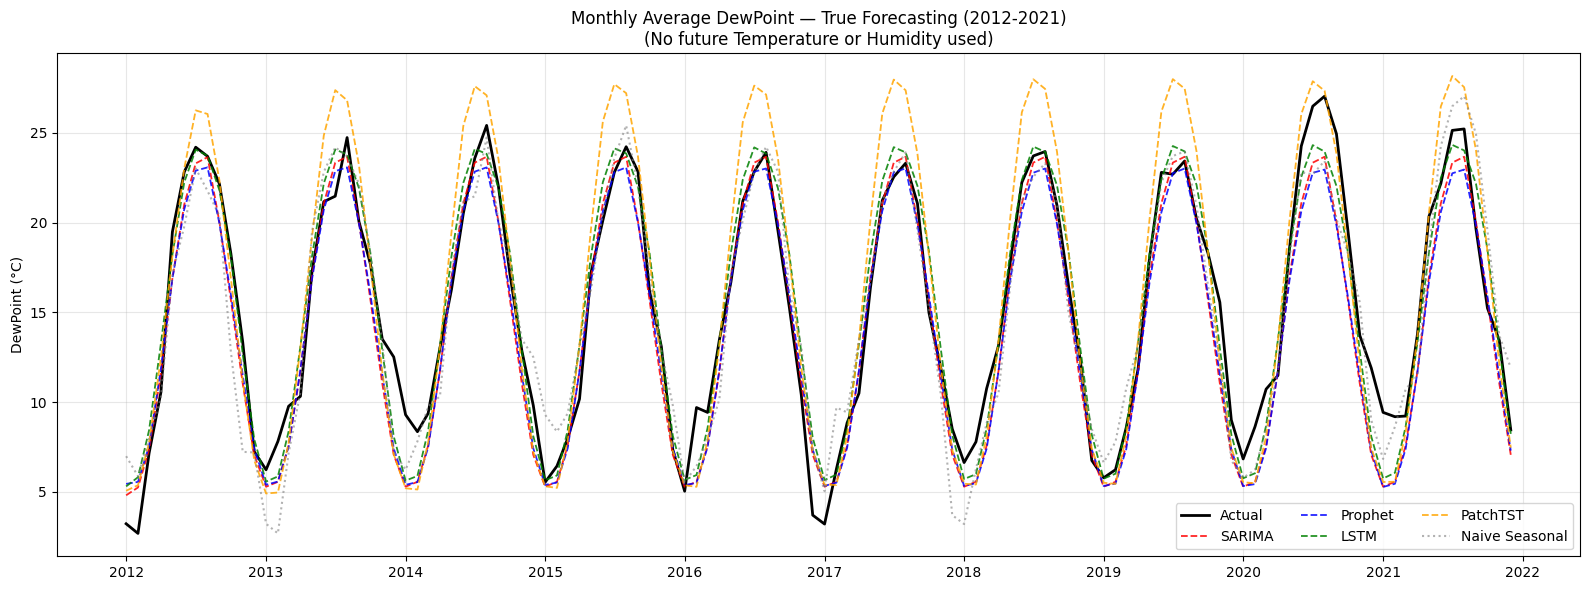

In [20]:
# Time series comparison plot (monthly averages)
test_dates_monthly = pd.to_datetime(true_monthly[["Year", "Month"]].assign(Day=1))
colors = {"SARIMA": "red", "Prophet": "blue", "LSTM": "green", "PatchTST": "orange"}

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_dates_monthly, true_monthly_dew, "k-", label="Actual", linewidth=2)
for name, color in colors.items():
    ax.plot(test_dates_monthly, all_results[name]["pred_monthly"], "--", color=color, label=name, linewidth=1.3, alpha=0.85)
ax.plot(test_dates_monthly, naive_dew, ":", color="gray", label="Naive Seasonal", alpha=0.6)
ax.set_title("Monthly Average DewPoint — True Forecasting (2012-2021)\n(No future Temperature or Humidity used)")
ax.set_ylabel("DewPoint (°C)")
ax.legend(ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

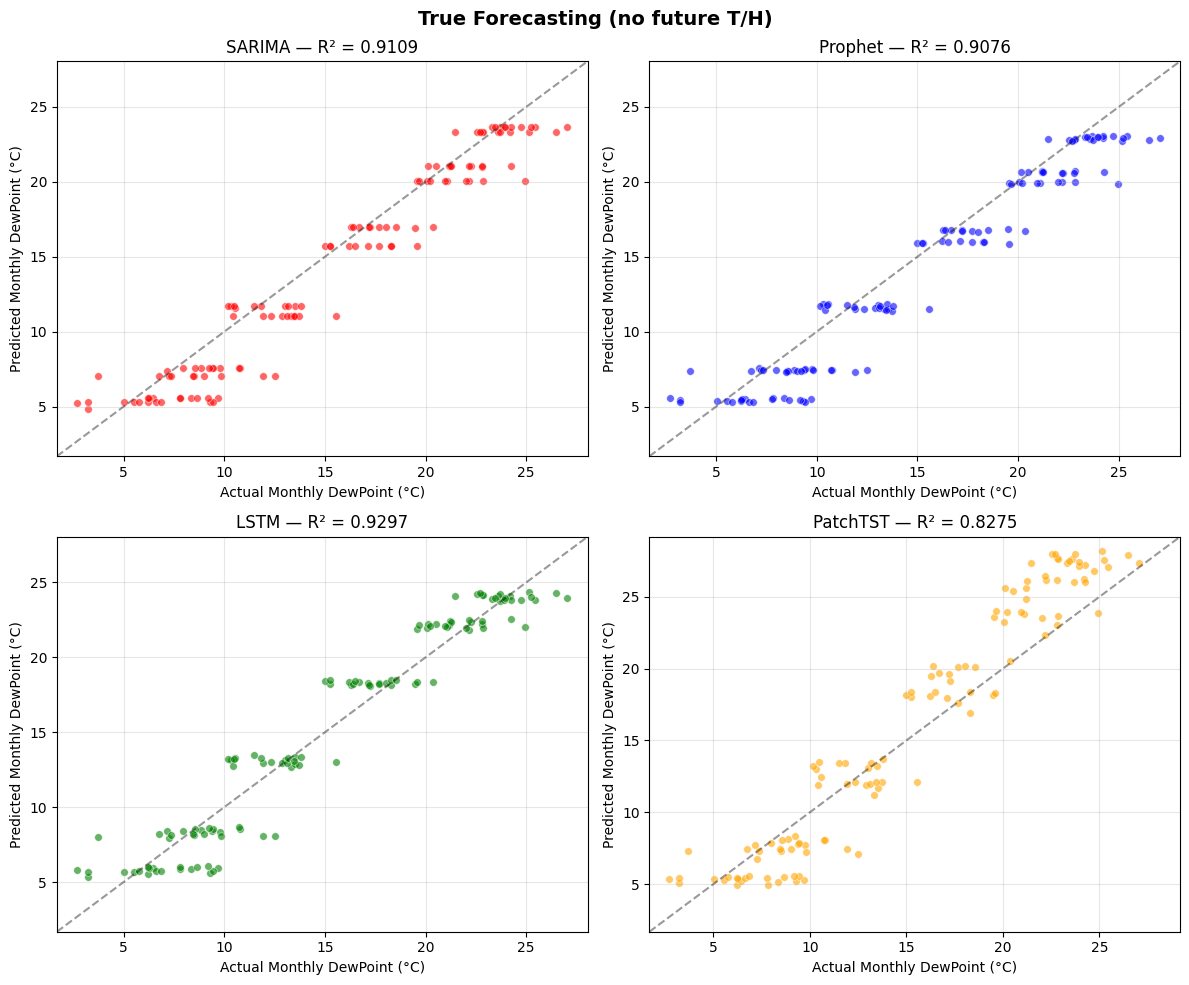

In [21]:
# Scatter plots: predicted vs actual monthly averages
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, color) in zip(axes.flat, colors.items()):
    pred = all_results[name]["pred_monthly"]
    r2 = r2_score(true_monthly_dew, pred)
    ax.scatter(true_monthly_dew, pred, c=color, alpha=0.6, s=30, edgecolors="white", linewidth=0.5)
    lims = [min(true_monthly_dew.min(), pred.min()) - 1, max(true_monthly_dew.max(), pred.max()) + 1]
    ax.plot(lims, lims, "k--", alpha=0.4)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual Monthly DewPoint (°C)")
    ax.set_ylabel("Predicted Monthly DewPoint (°C)")
    ax.set_title(f"{name} — R² = {r2:.4f}")
    ax.grid(True, alpha=0.3)

plt.suptitle("True Forecasting (no future T/H)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

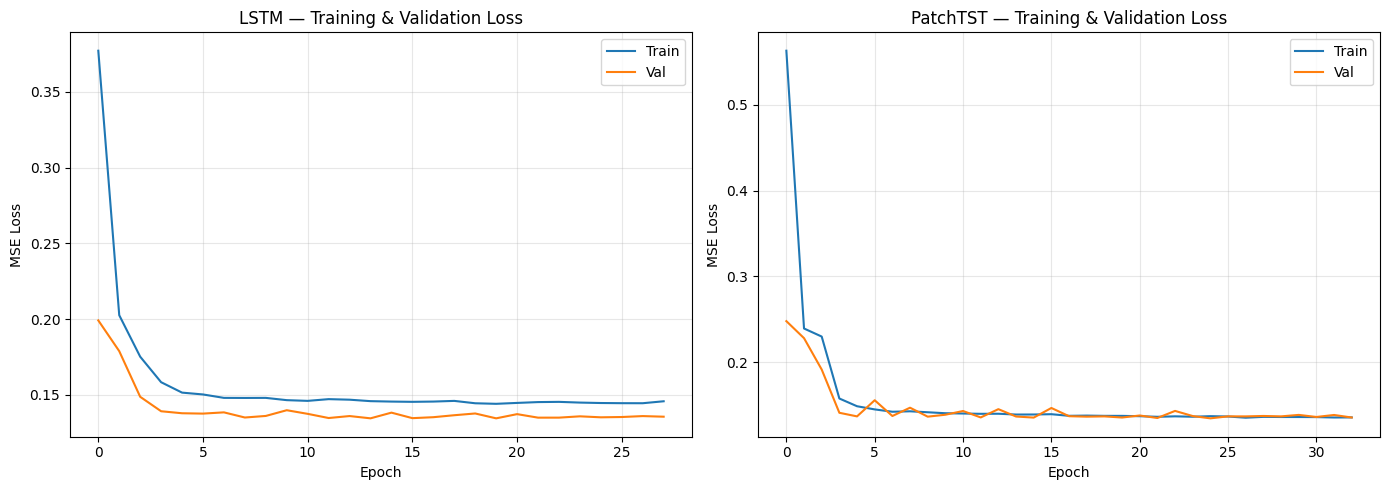

In [22]:
# NN training loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, tl, vl) in zip(axes, [("LSTM", lstm_train_losses, lstm_val_losses),
                                       ("PatchTST", ptst_train_losses, ptst_val_losses)]):
    ax.plot(tl, label="Train")
    ax.plot(vl, label="Val")
    ax.set_title(f"{name} — Training & Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

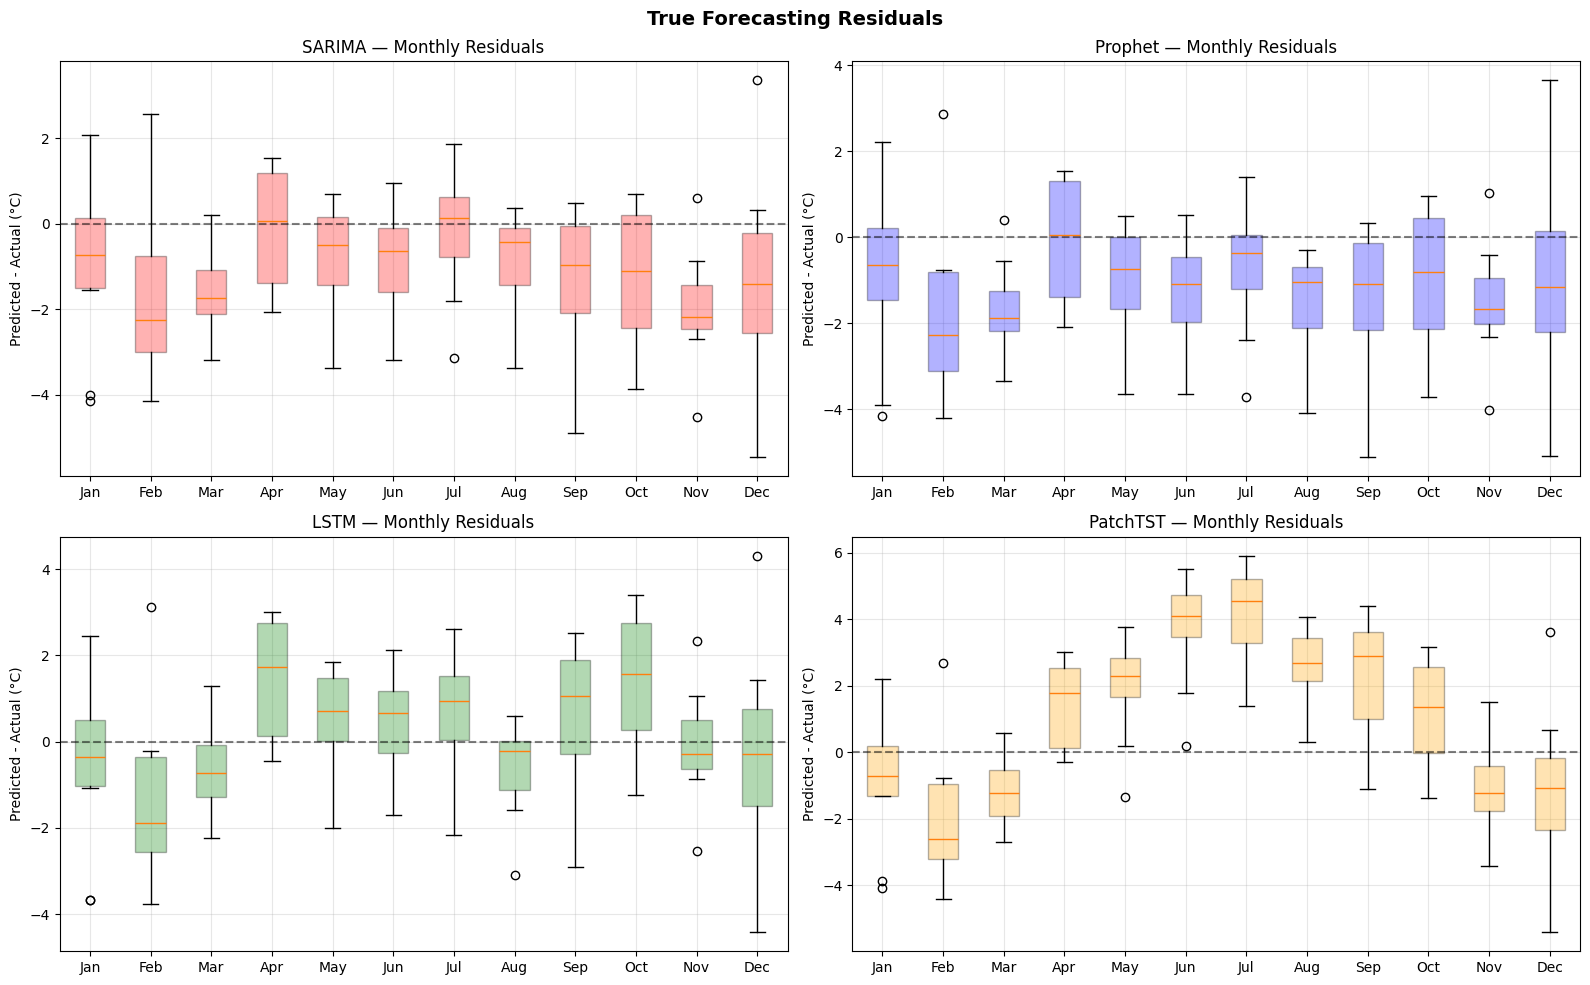

In [23]:
# Monthly residual boxplot per model
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
test_months = true_monthly["Month"].values
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for ax, (name, color) in zip(axes.flat, colors.items()):
    residuals = all_results[name]["pred_monthly"] - true_monthly_dew
    month_groups = [residuals[test_months == m] for m in range(1, 13)]
    bp = ax.boxplot(month_groups, labels=month_labels, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.3)
    ax.axhline(y=0, color="k", linestyle="--", alpha=0.5)
    ax.set_title(f"{name} — Monthly Residuals")
    ax.set_ylabel("Predicted - Actual (°C)")
    ax.grid(True, alpha=0.3)

plt.suptitle("True Forecasting Residuals", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [24]:
# Export all predictions and metrics
results_df = pd.DataFrame({
    "Year": true_monthly["Year"].values,
    "Month": true_monthly["Month"].values,
    "Actual_DewPoint": true_monthly_dew,
})
for name in ["SARIMA", "Prophet", "LSTM", "PatchTST", "Naive Seasonal", "Climatological Mean"]:
    col = name.replace(" ", "_")
    results_df[f"Pred_{col}"] = all_results[name]["pred_monthly"]
results_df.to_csv("all_models_predictions.csv", index=False)

rows = []
for name in ["SARIMA", "Prophet", "LSTM", "PatchTST", "Naive Seasonal", "Climatological Mean"]:
    r = all_results[name]
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(r["true_monthly"], r["pred_monthly"]),
        "RMSE": np.sqrt(mean_squared_error(r["true_monthly"], r["pred_monthly"])),
        "R2": r2_score(r["true_monthly"], r["pred_monthly"]),
    })
metrics_df = pd.DataFrame(rows)
metrics_df.to_csv("all_models_metrics.csv", index=False)
print("Exported: all_models_predictions.csv, all_models_metrics.csv")
metrics_df

Exported: all_models_predictions.csv, all_models_metrics.csv


,Model,MAE,RMSE,R2
0,SARIMA,1.534777,1.962230,0.910888
1,Prophet,1.581631,1.998495,0.907564
2,LSTM,1.363028,1.742935,0.929693
3,PatchTST,2.277248,2.729790,0.827538
4,Naive Seasonal,1.815685,2.272710,0.880457
5,Climatological Mean,1.895637,2.311923,0.876297
